<a href="https://colab.research.google.com/github/RajBhadani/Social_Network_Analysis-Report/blob/main/SNA_Report_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Applications of Social Network Analysis in Public Health and Security
**Authors:** Raj Bhadani and Pratyaksh  
**Course:** DSE Research Methodology, Deshbandhu College, University of Delhi (2025)  
**Supervisor:** Prof. Rakhi Saxena

---

## Overview
This notebook implements Social Network Analysis (SNA) across three case studies:
1. **Tobacco Control** — Multisectoral governance network (Mondal et al., 2022)
2. **COVID-19 Mask Discourse** — Twitter hashtag network (Ahmed et al., 2020)
3. **Terrorist Networks** — ISI brokerage role (Basu, 2005)

> **Note:** Synthetic data is used to reproduce the structural patterns from the original studies, as the raw datasets are not publicly available in full.

In [1]:
# ── Install & Import ─────────────────────────────────────────────────────────
!pip install networkx matplotlib numpy pandas seaborn -q

import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
print('Libraries loaded ✓')

Libraries loaded ✓


---
## Case Study 1: Tobacco Control Network
**Dataset:** Mondal et al. (2022) — 108 stakeholders across health, education, police, and municipal departments  
**SNA Metrics:** Betweenness Centrality, Degree Centrality, Network Density

In [2]:
# ── Synthetic Tobacco Control Network (replicates Mondal 2022 structure) ─────
np.random.seed(42)

# Define departments and stakeholder counts
departments = {
    'Health': 32,
    'Education': 28,
    'Police': 22,
    'Municipal': 26
}
dept_colors = {'Health': '#2196F3', 'Education': '#4CAF50', 'Police': '#FF5722', 'Municipal': '#9C27B0'}

G_tobacco = nx.Graph()

# Add nodes with department attribute
node_id = 0
dept_nodes = {}
for dept, count in departments.items():
    dept_nodes[dept] = list(range(node_id, node_id + count))
    for i in range(node_id, node_id + count):
        G_tobacco.add_node(i, department=dept, label=f'{dept[:3]}{i}')
    node_id += count

# Intra-department edges (higher probability)
for dept, nodes in dept_nodes.items():
    for i in nodes:
        for j in nodes:
            if i < j and np.random.random() < 0.35:
                G_tobacco.add_edge(i, j, weight=np.random.randint(1, 5))

# DTCC (District Tobacco Control Committee) as central hub — nodes 0-4 are key coordinators
dtcc_nodes = [0, 1, 2, 3, 4]  # Key Health dept coordinators
for dtcc in dtcc_nodes:
    for dept, nodes in dept_nodes.items():
        for n in np.random.choice(nodes, size=min(8, len(nodes)), replace=False):
            if dtcc != n:
                G_tobacco.add_edge(dtcc, n, weight=3)

# Cross-department edges (lower probability)
dept_list = list(dept_nodes.keys())
for i, d1 in enumerate(dept_list):
    for d2 in dept_list[i+1:]:
        nodes1 = dept_nodes[d1]
        nodes2 = dept_nodes[d2]
        for _ in range(int(len(nodes1) * 0.2)):
            n1 = np.random.choice(nodes1)
            n2 = np.random.choice(nodes2)
            G_tobacco.add_edge(n1, n2, weight=1)

print(f'Tobacco Network — Nodes: {G_tobacco.number_of_nodes()}, Edges: {G_tobacco.number_of_edges()}')
print(f'Network Density: {nx.density(G_tobacco):.4f}')

Tobacco Network — Nodes: 108, Edges: 665
Network Density: 0.1151


In [3]:
# ── SNA Metrics: Tobacco Control ─────────────────────────────────────────────
betweenness = nx.betweenness_centrality(G_tobacco, normalized=True)
degree_cent  = nx.degree_centrality(G_tobacco)
closeness    = nx.closeness_centrality(G_tobacco)

df_tobacco = pd.DataFrame({
    'Node': list(G_tobacco.nodes()),
    'Department': [G_tobacco.nodes[n]['department'] for n in G_tobacco.nodes()],
    'Betweenness': [betweenness[n] for n in G_tobacco.nodes()],
    'Degree_Centrality': [degree_cent[n] for n in G_tobacco.nodes()],
    'Closeness': [closeness[n] for n in G_tobacco.nodes()]
})

print('Top 10 nodes by Betweenness Centrality (DTCC-like coordinators):')
print(df_tobacco.nlargest(10, 'Betweenness')[['Node','Department','Betweenness','Degree_Centrality']].to_string(index=False))

print('\nDensity by Department:')
for dept, nodes in dept_nodes.items():
    sub = G_tobacco.subgraph(nodes)
    print(f'  {dept}: {nx.density(sub):.4f}')

Top 10 nodes by Betweenness Centrality (DTCC-like coordinators):
 Node Department  Betweenness  Degree_Centrality
    2     Health     0.148507           0.401869
    0     Health     0.146431           0.383178
    1     Health     0.129653           0.383178
    4     Health     0.120597           0.383178
    3     Health     0.120372           0.355140
   33  Education     0.019058           0.149533
   42  Education     0.013963           0.130841
   52  Education     0.013536           0.130841
   53  Education     0.013348           0.112150
   48  Education     0.012515           0.112150

Density by Department:
  Health: 0.3690
  Education: 0.3413
  Police: 0.3680
  Municipal: 0.3569


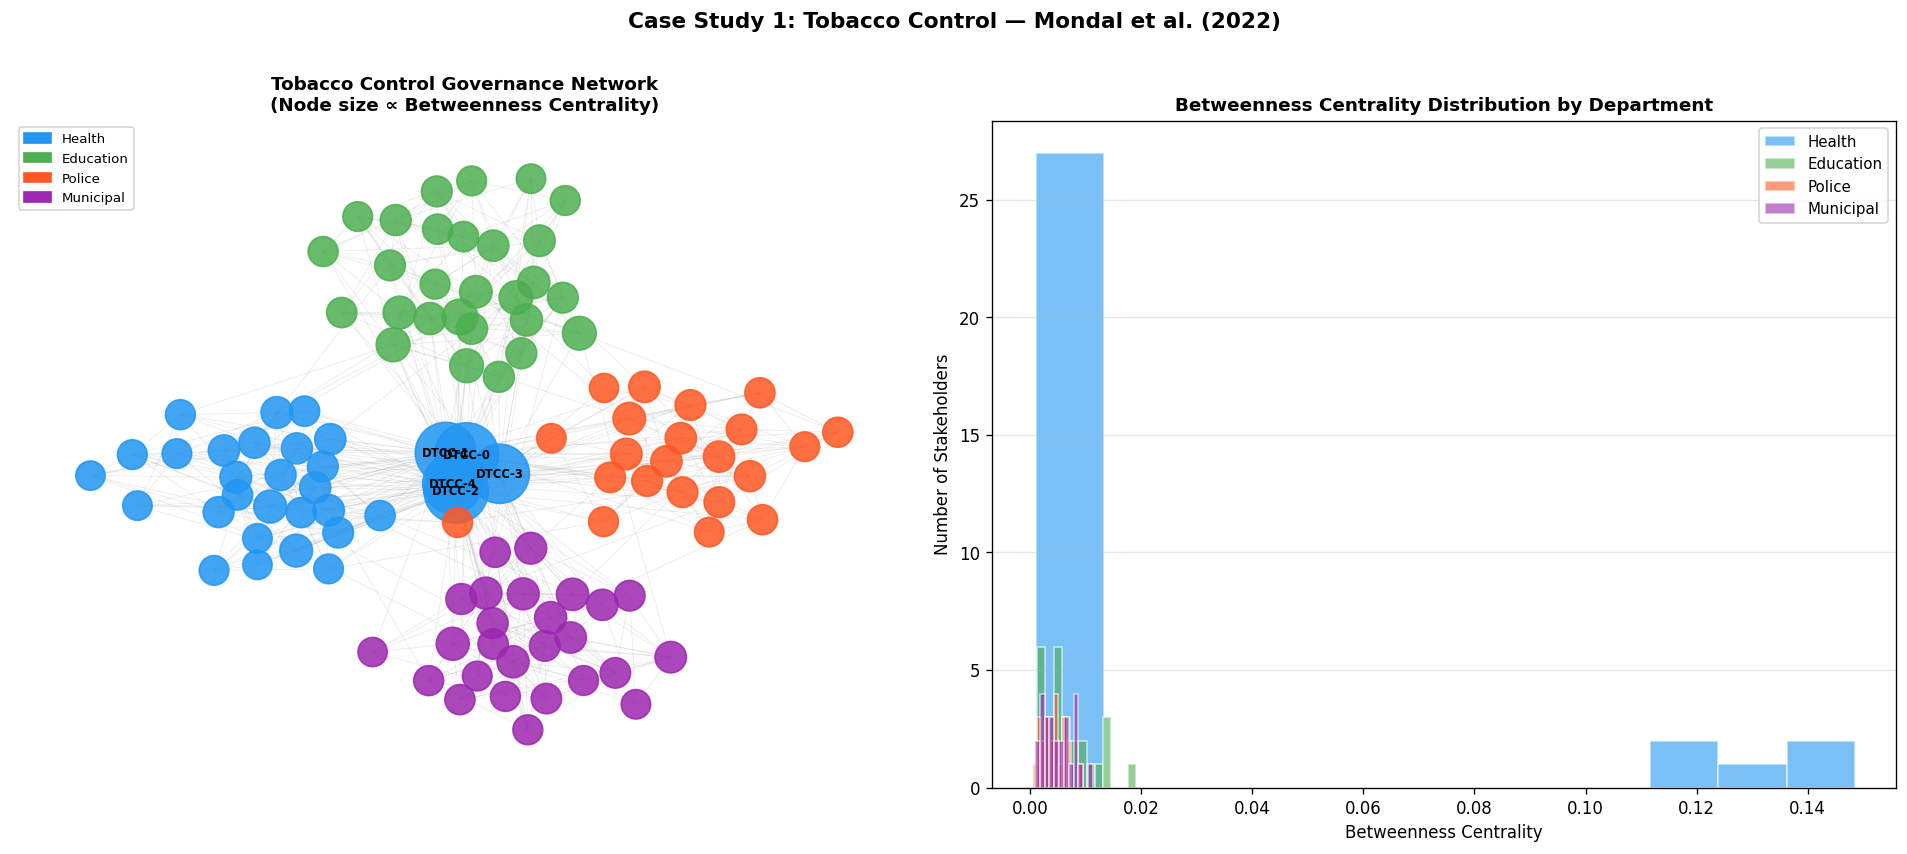

Figure saved: tobacco_network.png


In [4]:
# ── Visualisation: Tobacco Network ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Network graph
ax = axes[0]
pos = nx.spring_layout(G_tobacco, seed=42, k=0.4)
node_colors = [dept_colors[G_tobacco.nodes[n]['department']] for n in G_tobacco.nodes()]
node_sizes  = [300 + betweenness[n] * 8000 for n in G_tobacco.nodes()]

nx.draw_networkx_edges(G_tobacco, pos, ax=ax, alpha=0.15, edge_color='gray', width=0.5)
nx.draw_networkx_nodes(G_tobacco, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.85)

# Label top 5 nodes
top5 = df_tobacco.nlargest(5, 'Betweenness')['Node'].tolist()
labels = {n: f"DTCC-{n}" if n in dtcc_nodes else str(n) for n in top5}
nx.draw_networkx_labels(G_tobacco, pos, labels=labels, ax=ax, font_size=7, font_weight='bold')

legend_patches = [mpatches.Patch(color=c, label=d) for d, c in dept_colors.items()]
ax.legend(handles=legend_patches, loc='upper left', fontsize=8)
ax.set_title('Tobacco Control Governance Network\n(Node size ∝ Betweenness Centrality)', fontsize=11, fontweight='bold')
ax.axis('off')

# Centrality distribution
ax2 = axes[1]
for dept, color in dept_colors.items():
    subset = df_tobacco[df_tobacco['Department'] == dept]['Betweenness']
    ax2.hist(subset, bins=12, alpha=0.6, color=color, label=dept, edgecolor='white')
ax2.set_xlabel('Betweenness Centrality', fontsize=10)
ax2.set_ylabel('Number of Stakeholders', fontsize=10)
ax2.set_title('Betweenness Centrality Distribution by Department', fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Case Study 1: Tobacco Control — Mondal et al. (2022)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('tobacco_network.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: tobacco_network.png')

---
## Case Study 2: COVID-19 Mask Discourse on Twitter
**Dataset:** Ahmed et al. (2020) — 452,430 tweets; 4,525 analyzed for network structure  
**SNA Metrics:** Betweenness Centrality (influencer identification), Hashtag co-occurrence network

In [5]:
# ── Synthetic Twitter Hashtag Co-occurrence Network ───────────────────────────
np.random.seed(7)

# Core hashtags from the COVID-19 mask discourse (Ahmed 2020 themes)
core_hashtags = [
    '#WearAMask', '#COVID19', '#Masks4All', '#StaySafe', '#Coronavirus',
    '#MaskUp', '#PublicHealth', '#SocialDistancing', '#FlattenTheCurve',
    '#MaskMandate', '#NoMaskNoService', '#MaskWearing', '#COVID', '#Pandemic',
    '#MaskProtects', '#HealthAdvice', '#WHO', '#CDC', '#CovidResponse',
    '#MaskSave', '#WearIt', '#ProtectOthers', '#MaskDebate', '#AntiMask'
]

G_twitter = nx.Graph()
G_twitter.add_nodes_from(core_hashtags)

# Co-occurrence weights — simulate frequency-based connections
# High-frequency pairs (dominant discourse)
strong_pairs = [
    ('#WearAMask', '#COVID19', 180), ('#WearAMask', '#Masks4All', 145),
    ('#COVID19', '#StaySafe', 132), ('#COVID19', '#Coronavirus', 210),
    ('#MaskUp', '#WearAMask', 98), ('#PublicHealth', '#COVID19', 87),
    ('#SocialDistancing', '#COVID19', 120), ('#FlattenTheCurve', '#COVID19', 95),
    ('#MaskMandate', '#WearAMask', 76), ('#WHO', '#COVID19', 88),
    ('#CDC', '#MaskMandate', 65), ('#MaskDebate', '#AntiMask', 54),
    ('#WearAMask', '#ProtectOthers', 72), ('#StaySafe', '#MaskUp', 61),
]
for h1, h2, w in strong_pairs:
    G_twitter.add_edge(h1, h2, weight=w)

# Random weaker co-occurrences
for i, h1 in enumerate(core_hashtags):
    for h2 in core_hashtags[i+1:]:
        if not G_twitter.has_edge(h1, h2) and np.random.random() < 0.25:
            G_twitter.add_edge(h1, h2, weight=np.random.randint(5, 40))

btw_twitter = nx.betweenness_centrality(G_twitter, weight='weight', normalized=True)
deg_twitter  = dict(G_twitter.degree(weight='weight'))

df_twitter = pd.DataFrame({
    'Hashtag': list(btw_twitter.keys()),
    'Betweenness': list(btw_twitter.values()),
    'Weighted_Degree': [deg_twitter[n] for n in btw_twitter.keys()]
}).sort_values('Betweenness', ascending=False)

print(f'Twitter Network — Nodes: {G_twitter.number_of_nodes()}, Edges: {G_twitter.number_of_edges()}')
print(f'Density: {nx.density(G_twitter):.4f}')
print('\nTop 10 Influencer Hashtags (Betweenness Centrality):')
print(df_twitter.head(10).to_string(index=False))

Twitter Network — Nodes: 24, Edges: 76
Density: 0.2754

Top 10 Influencer Hashtags (Betweenness Centrality):
         Hashtag  Betweenness  Weighted_Degree
          #COVID     0.227273              129
   #MaskProtects     0.182477              138
    #MaskWearing     0.159420               97
   #PublicHealth     0.138340              247
     #MaskDebate     0.104084              144
       #Pandemic     0.102767              127
         #MaskUp     0.100791              314
#FlattenTheCurve     0.098155              261
   #HealthAdvice     0.073123              201
#NoMaskNoService     0.065217               76


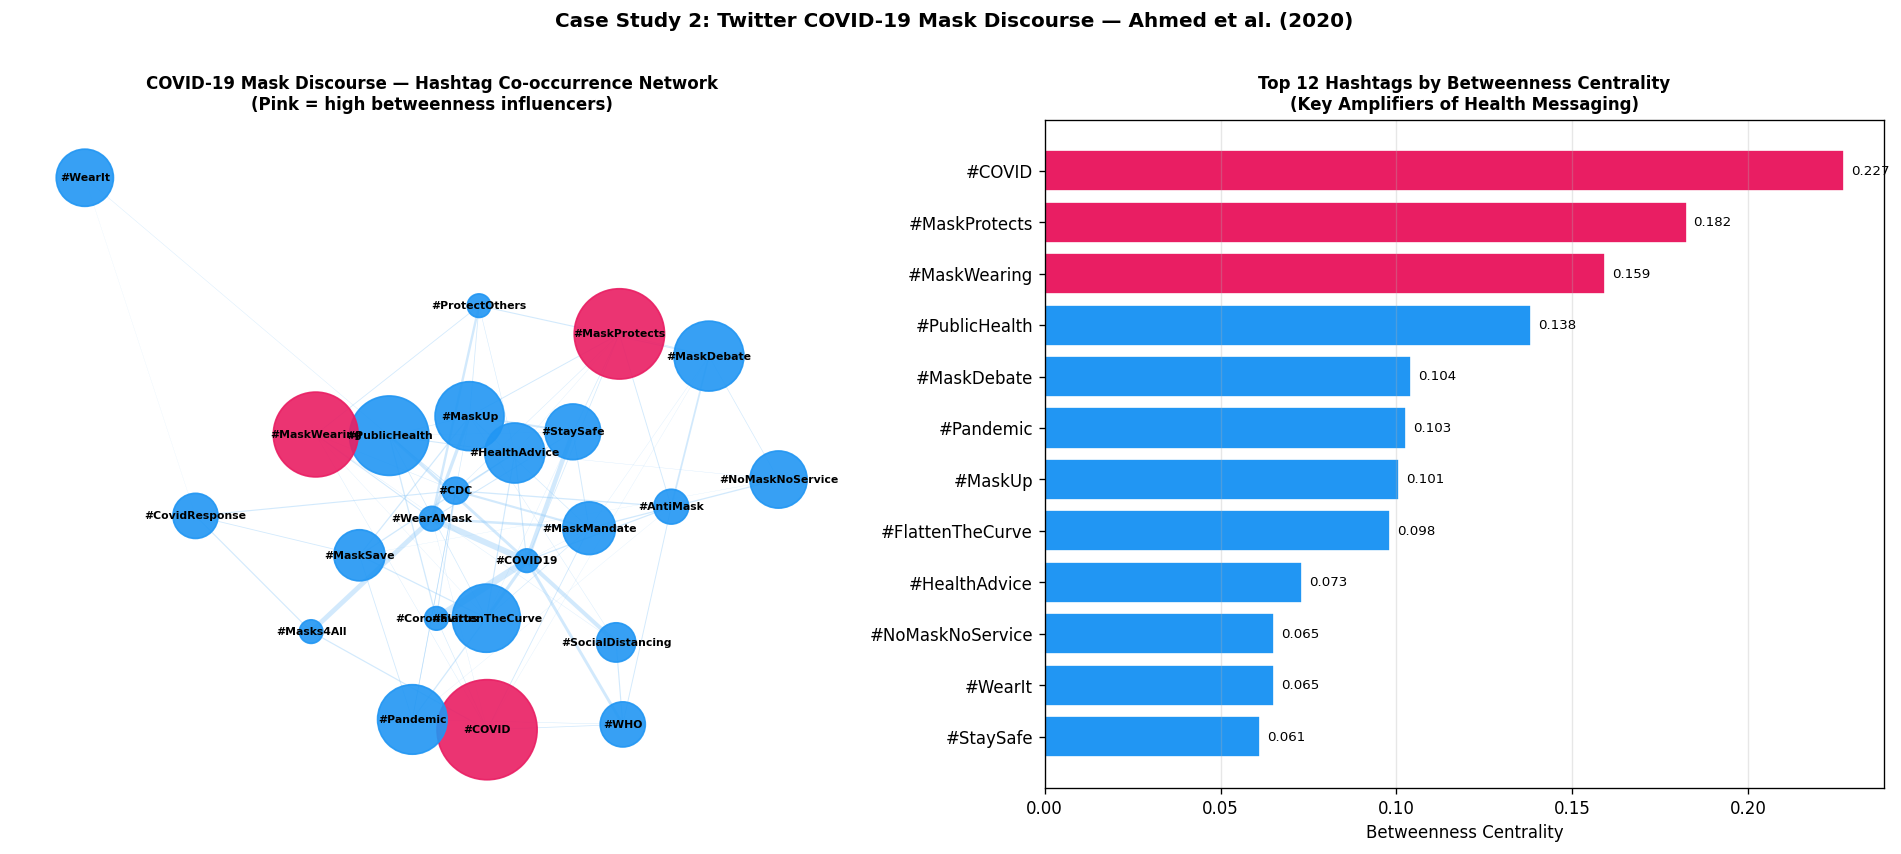

Figure saved: twitter_network.png


In [6]:
# ── Visualisation: Twitter Hashtag Network + Hashtag Cloud Proxy ─────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Network graph
ax1 = axes[0]
pos_tw = nx.spring_layout(G_twitter, seed=10, k=1.2)
edge_weights = [G_twitter[u][v]['weight'] / 50 for u, v in G_twitter.edges()]
node_sizes_tw = [200 + btw_twitter[n] * 15000 for n in G_twitter.nodes()]
node_colors_tw = ['#E91E63' if btw_twitter[n] > 0.15 else '#2196F3' for n in G_twitter.nodes()]

nx.draw_networkx_edges(G_twitter, pos_tw, ax=ax1, width=edge_weights, alpha=0.4, edge_color='#90CAF9')
nx.draw_networkx_nodes(G_twitter, pos_tw, ax=ax1, node_color=node_colors_tw, node_size=node_sizes_tw, alpha=0.9)
nx.draw_networkx_labels(G_twitter, pos_tw, ax=ax1, font_size=6.5, font_weight='bold')
ax1.set_title('COVID-19 Mask Discourse — Hashtag Co-occurrence Network\n(Pink = high betweenness influencers)', fontsize=10, fontweight='bold')
ax1.axis('off')

# Bar chart — Top influencer hashtags
ax2 = axes[1]
top_df = df_twitter.head(12)
colors_bar = ['#E91E63' if b > 0.15 else '#2196F3' for b in top_df['Betweenness']]
bars = ax2.barh(top_df['Hashtag'][::-1], top_df['Betweenness'][::-1], color=colors_bar[::-1], edgecolor='white')
ax2.set_xlabel('Betweenness Centrality', fontsize=10)
ax2.set_title('Top 12 Hashtags by Betweenness Centrality\n(Key Amplifiers of Health Messaging)', fontsize=10, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_df['Betweenness'][::-1]):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)

plt.suptitle('Case Study 2: Twitter COVID-19 Mask Discourse — Ahmed et al. (2020)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('twitter_network.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: twitter_network.png')

---
## Case Study 3: Terrorist Networks in India — ISI Brokerage Role
**Dataset:** Basu (2005) — Co-occurrence data from media reports on 61 terrorist organizations  
**SNA Metrics:** Betweenness Centrality (ISI brokerage), Network structure analysis

> **Key finding:** Despite having few direct links, ISI occupies a high-betweenness brokerage position connecting otherwise disconnected clusters of organizations.

In [7]:
# ── Terrorist Network — Basu (2005) Structure ────────────────────────────────
np.random.seed(99)

# 61 organizations grouped by affiliation clusters
clusters = {
    'Pakistan-based': ['ISI', 'LeT', 'JeM', 'HuM', 'HM', 'Al-Badr', 'HUJI-B', 'TTP-affiliate'],
    'Northeast India': ['ULFA', 'NDFB', 'NLFT', 'ATTF', 'PLA-Manipur', 'KYKL', 'RPF', 'PREPAK'],
    'Kashmir': ['HM', 'JKLF', 'Al-Umar', 'Muslim-Janbaz', 'Ikhwan', 'Al-Mansoorian', 'TM'],
    'Left-Wing': ['CPI-M', 'PWG', 'MCC', 'MCCI', 'CRC-CPI', 'TPC', 'PLFI', 'JTJM'],
    'South India': ['LTTE', 'EPRLF', 'PLOTE', 'TELO', 'ENDLF', 'TNLA'],
    'Central India': ['SIMI', 'IM', 'HuJI-India', 'AuT', 'NDFB-S', 'BLTO', 'CTGC'],
    'Minor-groups': [f'Grp{i}' for i in range(1, 14)]
}

all_orgs = [org for orgs in clusters.values() for org in orgs]
# Ensure exactly 61 orgs
all_orgs = all_orgs[:61]

G_terror = nx.Graph()
G_terror.add_nodes_from(all_orgs)

# Assign cluster attribute
org_to_cluster = {org: cluster for cluster, orgs in clusters.items() for org in orgs}
for org in G_terror.nodes():
    G_terror.nodes[org]['cluster'] = org_to_cluster.get(org, 'Minor-groups')

# Intra-cluster edges
for cluster_name, orgs in clusters.items():
    orgs_in_graph = [o for o in orgs if o in G_terror.nodes()]
    for i, o1 in enumerate(orgs_in_graph):
        for o2 in orgs_in_graph[i+1:]:
            if np.random.random() < 0.55:
                G_terror.add_edge(o1, o2)

# ISI as broker — connect to representatives of each cluster
# (high betweenness despite moderate degree — Basu 2005 finding)
isi_connections = ['LeT', 'JeM', 'HuM', 'HM', 'ULFA', 'NDFB', 'JKLF', 'SIMI', 'LTTE', 'CPI-M', 'HUJI-B', 'Al-Badr']
for org in isi_connections:
    if org in G_terror.nodes():
        G_terror.add_edge('ISI', org)

# Sparse cross-cluster edges (few direct links between clusters except via ISI)
cluster_list = list(clusters.keys())
for i, c1 in enumerate(cluster_list[1:], 1):  # Exclude Pakistan-based
    for c2 in cluster_list[i+1:]:
        orgs1 = [o for o in clusters[c1] if o in G_terror.nodes()]
        orgs2 = [o for o in clusters[c2] if o in G_terror.nodes()]
        if orgs1 and orgs2 and np.random.random() < 0.2:
            G_terror.add_edge(np.random.choice(orgs1), np.random.choice(orgs2))

btw_terror = nx.betweenness_centrality(G_terror, normalized=True)
deg_terror  = dict(G_terror.degree())

df_terror = pd.DataFrame({
    'Organization': list(btw_terror.keys()),
    'Cluster': [G_terror.nodes[n]['cluster'] for n in btw_terror.keys()],
    'Betweenness': list(btw_terror.values()),
    'Degree': [deg_terror[n] for n in btw_terror.keys()]
}).sort_values('Betweenness', ascending=False)

print(f'Terror Network — Nodes: {G_terror.number_of_nodes()}, Edges: {G_terror.number_of_edges()}')
print(f'Density: {nx.density(G_terror):.4f}')
print(f'\nISI Betweenness Centrality: {btw_terror["ISI"]:.4f}')
print(f'ISI Degree: {deg_terror["ISI"]}')
print('\nTop 10 Organizations by Betweenness (Brokerage Role):')
print(df_terror.head(10)[['Organization','Cluster','Betweenness','Degree']].to_string(index=False))

Terror Network — Nodes: 56, Edges: 128
Density: 0.0831

ISI Betweenness Centrality: 0.3639
ISI Degree: 13

Top 10 Organizations by Betweenness (Brokerage Role):
Organization         Cluster  Betweenness  Degree
         ISI  Pakistan-based     0.363883      13
       CPI-M       Left-Wing     0.170056       6
        LTTE     South India     0.130191       6
          HM         Kashmir     0.123838       8
         AuT   Central India     0.088406       4
        SIMI   Central India     0.085039       2
 PLA-Manipur Northeast India     0.069753       8
        ULFA Northeast India     0.057015       8
      NDFB-S   Central India     0.053872       2
        JKLF         Kashmir     0.042469       4


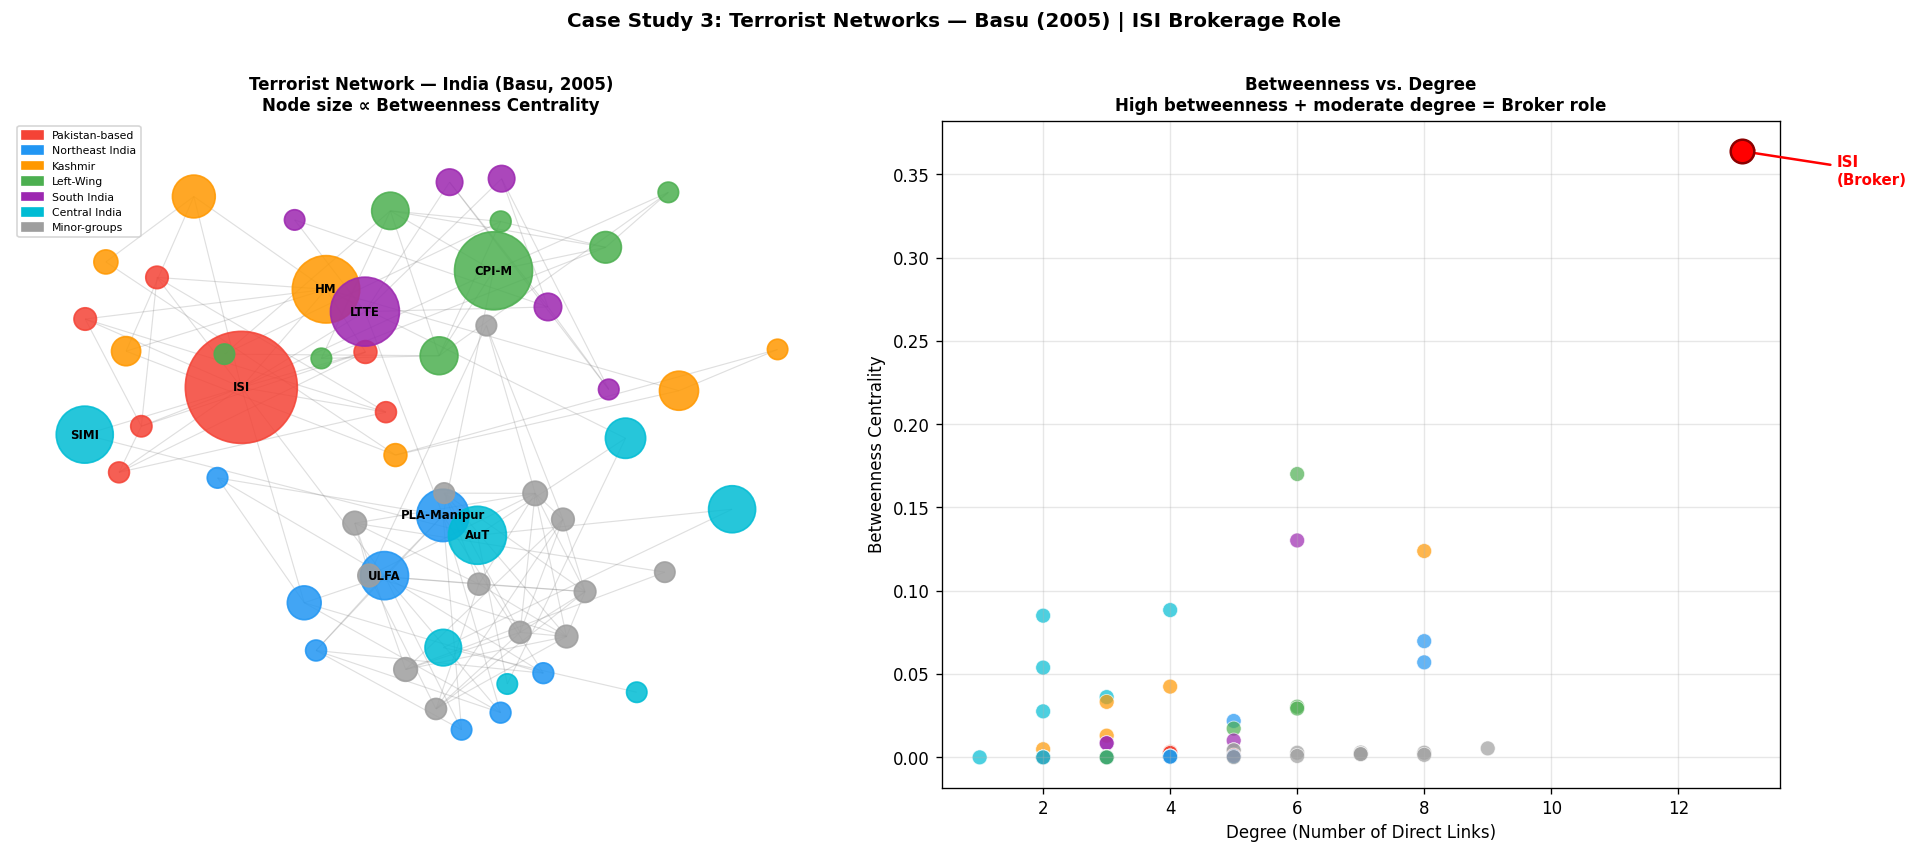

Figure saved: terrorist_network.png


In [8]:
# ── Visualisation: Terrorist Network ─────────────────────────────────────────
cluster_colors = {
    'Pakistan-based': '#F44336',
    'Northeast India': '#2196F3',
    'Kashmir': '#FF9800',
    'Left-Wing': '#4CAF50',
    'South India': '#9C27B0',
    'Central India': '#00BCD4',
    'Minor-groups': '#9E9E9E'
}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Network graph
ax1 = axes[0]
pos_terror = nx.spring_layout(G_terror, seed=42, k=0.9)
node_colors_t = [cluster_colors.get(G_terror.nodes[n]['cluster'], '#9E9E9E') for n in G_terror.nodes()]
node_sizes_t  = [150 + btw_terror[n] * 12000 for n in G_terror.nodes()]

nx.draw_networkx_edges(G_terror, pos_terror, ax=ax1, alpha=0.25, edge_color='gray', width=0.7)
nx.draw_networkx_nodes(G_terror, pos_terror, ax=ax1, node_color=node_colors_t, node_size=node_sizes_t, alpha=0.85)

# Label top 8 by betweenness
top8 = df_terror.head(8)['Organization'].tolist()
labels_t = {n: n for n in G_terror.nodes() if n in top8}
nx.draw_networkx_labels(G_terror, pos_terror, labels=labels_t, ax=ax1, font_size=7, font_weight='bold')

legend_patches_t = [mpatches.Patch(color=c, label=cl) for cl, c in cluster_colors.items()]
ax1.legend(handles=legend_patches_t, loc='upper left', fontsize=6.5)
ax1.set_title('Terrorist Network — India (Basu, 2005)\nNode size ∝ Betweenness Centrality', fontsize=10, fontweight='bold')
ax1.axis('off')

# Betweenness vs Degree scatter — ISI highlighted
ax2 = axes[1]
colors_scatter = [cluster_colors.get(G_terror.nodes[n]['cluster'], '#9E9E9E') for n in G_terror.nodes()]
ax2.scatter(df_terror['Degree'], df_terror['Betweenness'], c=[cluster_colors.get(cl, '#9E9E9E') for cl in df_terror['Cluster']], s=80, alpha=0.7, edgecolors='white', linewidths=0.5)

# Annotate ISI
isi_row = df_terror[df_terror['Organization'] == 'ISI'].iloc[0]
ax2.annotate('ISI\n(Broker)', xy=(isi_row['Degree'], isi_row['Betweenness']),
             xytext=(isi_row['Degree']+1.5, isi_row['Betweenness']-0.02),
             arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
             fontsize=9, fontweight='bold', color='red')
ax2.scatter([isi_row['Degree']], [isi_row['Betweenness']], color='red', s=200, zorder=5, edgecolors='darkred', linewidths=1.5)

ax2.set_xlabel('Degree (Number of Direct Links)', fontsize=10)
ax2.set_ylabel('Betweenness Centrality', fontsize=10)
ax2.set_title('Betweenness vs. Degree\nHigh betweenness + moderate degree = Broker role', fontsize=10, fontweight='bold')
ax2.grid(alpha=0.3)

plt.suptitle('Case Study 3: Terrorist Networks — Basu (2005) | ISI Brokerage Role', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('terrorist_network.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: terrorist_network.png')

---
## Comparative Analysis: All Three Networks

In [9]:
# ── Cross-Network Comparison ──────────────────────────────────────────────────
summary = {
    'Network': ['Tobacco Control', 'Twitter (COVID-19)', 'Terrorist (India)'],
    'Nodes': [G_tobacco.number_of_nodes(), G_twitter.number_of_nodes(), G_terror.number_of_nodes()],
    'Edges': [G_tobacco.number_of_edges(), G_twitter.number_of_edges(), G_terror.number_of_edges()],
    'Density': [round(nx.density(G_tobacco), 4), round(nx.density(G_twitter), 4), round(nx.density(G_terror), 4)],
    'Avg_Clustering': [
        round(nx.average_clustering(G_tobacco), 4),
        round(nx.average_clustering(G_twitter), 4),
        round(nx.average_clustering(G_terror), 4)
    ],
    'Max_Betweenness_Node': [
        max(betweenness, key=betweenness.get),
        max(btw_twitter, key=btw_twitter.get),
        max(btw_terror, key=btw_terror.get)
    ],
    'Max_Betweenness_Value': [
        round(max(betweenness.values()), 4),
        round(max(btw_twitter.values()), 4),
        round(max(btw_terror.values()), 4)
    ]
}

df_summary = pd.DataFrame(summary)
print('Cross-Network Comparative Summary')
print('=' * 70)
print(df_summary.to_string(index=False))

Cross-Network Comparative Summary
           Network  Nodes  Edges  Density  Avg_Clustering Max_Betweenness_Node  Max_Betweenness_Value
   Tobacco Control    108    665   0.1151          0.3081                    2                 0.1485
Twitter (COVID-19)     24     76   0.2754          0.2563               #COVID                 0.2273
 Terrorist (India)     56    128   0.0831          0.5090                  ISI                 0.3639


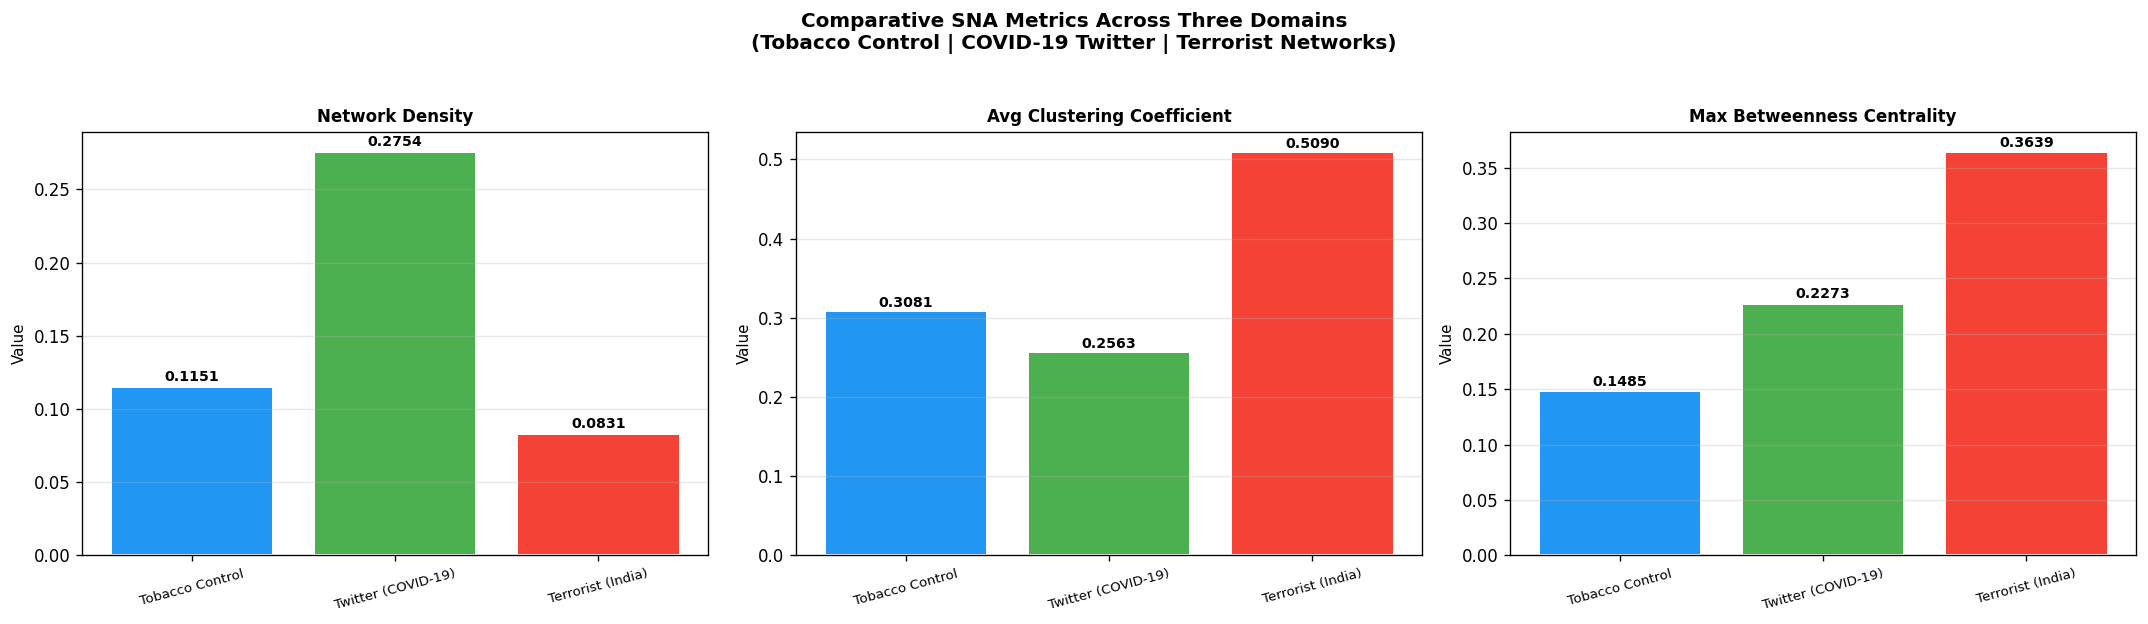

Figure saved: comparative_analysis.png


In [10]:
# ── Final Comparative Visualisation ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Density', 'Avg_Clustering', 'Max_Betweenness_Value']
metric_labels = ['Network Density', 'Avg Clustering Coefficient', 'Max Betweenness Centrality']
bar_colors = ['#2196F3', '#4CAF50', '#F44336']

for ax, metric, label in zip(axes, metrics, metric_labels):
    bars = ax.bar(df_summary['Network'], df_summary[metric], color=bar_colors, edgecolor='white', linewidth=1.2)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Value', fontsize=9)
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_summary[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}',
                ha='center', va='bottom', fontsize=8.5, fontweight='bold')

plt.suptitle('Comparative SNA Metrics Across Three Domains\n(Tobacco Control | COVID-19 Twitter | Terrorist Networks)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('comparative_analysis.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: comparative_analysis.png')

---
## Conclusion

| Domain | Key Actor | SNA Metric Used | Finding |
|--------|-----------|-----------------|----------|
| Tobacco Control | DTCC (Health dept coordinators) | Betweenness + Density | Governance gaps identified; cross-sector collaboration low |
| COVID-19 Twitter | `#WearAMask`, `#COVID19` | Betweenness Centrality | Top hashtags act as bridges for health messaging amplification |
| Terrorist Networks | ISI | Betweenness Centrality | Brokerage role confirmed — high betweenness despite moderate degree |

**Limitations:**
- Static SNA snapshots miss temporal evolution of networks
- Open-source data lacks granularity (Twitter noise, incomplete terror network reports)

**References:**
1. Mondal et al. (2022). *BMJ Global Health*
2. Ahmed et al. (2020). *Int. Journal of Environmental Research and Public Health*
3. Basu (2005). *ResearchGate*